# Taller Final Integrador — Clustering aplicado a una imagen

**Imagen seleccionada:** colibrí con colores vivos.  
**Tipo de problema:** aprendizaje no supervisado mediante clustering sobre píxeles.  
**Algoritmos comparados:** K-Means y Mean Shift.  
**Objetivo general:** segmentar la imagen agrupando colores similares para identificar regiones visuales sin usar etiquetas previas.


## 1. Información del equipo

Integrantes del grupo:

1.   Ainoa Bolea Villa
2.   Santiago Gonzalez Garzon
3.   Mateo Giraldo Soto
4.   Juan Jose Velez Mejia

Dataset o imagen seleccionada: Imagen del colibrí nombrada como image.png

Tipo de problema: clustering / aprendizaje no supervisado aplicado a segmentación de imagen.


## 2. Entendimiento del problema

El clustering consiste en agrupar datos similares sin usar una respuesta conocida. En este caso, cada píxel de la imagen se interpreta como una observación y sus canales de color RGB se usan como variables. El objetivo es descubrir grupos de colores parecidos y reconstruir versiones segmentadas de la imagen.

Este enfoque permite simplificar visualmente la imagen, reducir la cantidad de colores y observar qué regiones comparten características cromáticas similares.


## 3. Importar librerías

Se cargan librerías para manejo numérico, visualización, procesamiento de imágenes, escalamiento, clustering y evaluación de calidad de los clusters.


In [ ]:
# Librerías para manejo de datos numéricos
import numpy as np
import pandas as pd

# Librerías para visualización
import matplotlib.pyplot as plt

# Librería para abrir y procesar imágenes
from PIL import Image

# Herramientas de clustering y preprocesamiento
from sklearn.cluster import KMeans, MeanShift, estimate_bandwidth
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA

# Librerías auxiliares
from pathlib import Path


### Interpretación

Estas librerías permiten desarrollar todo el flujo del taller: cargar la imagen, convertirla en datos numéricos, preparar los píxeles, aplicar algoritmos de clustering, evaluar resultados y visualizar la segmentación obtenida.


## 4. Carga de la imagen

Se carga la imagen del colibrí desde una ruta local del entorno del notebook. En este caso, la imagen debe estar en la misma carpeta del notebook con el nombre `image.png`.


Ruta usada: /content/image.png
Formato de trabajo: RGBA
Tamaño de la imagen: (720, 893)


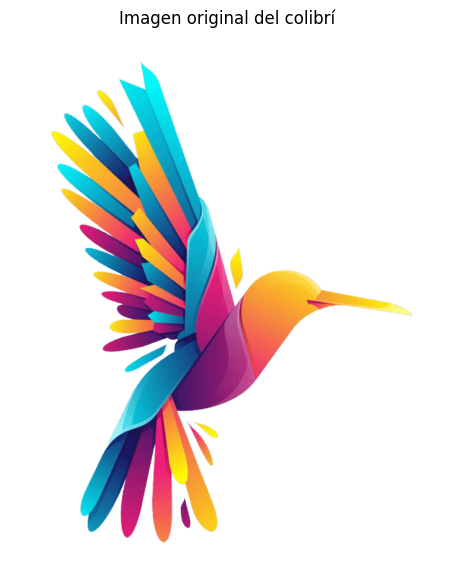

In [ ]:
# Ruta de la imagen dentro de los archivos del notebook
# Si tu archivo tiene otro nombre, cambia únicamente este valor.
image_path = Path("/content/image.png")

# Validar que la imagen exista antes de continuar
if not image_path.exists():
    raise FileNotFoundError(
        f"No se encontró la imagen en la ruta: {image_path}. "
        "Verifica que el archivo esté subido en la misma carpeta del notebook."
    )

# Abrir imagen en formato RGBA para conservar transparencia si existe
img_rgba = Image.open(image_path).convert("RGBA")

# Mostrar información básica de la imagen
print("Ruta usada:", image_path)
print("Formato de trabajo:", img_rgba.mode)
print("Tamaño de la imagen:", img_rgba.size)

# Visualizar imagen original
plt.figure(figsize=(6, 7))
plt.imshow(img_rgba)
plt.axis("off")
plt.title("Imagen original del colibrí")
plt.show()


### Interpretación

La imagen se abre en formato RGBA, lo que significa que contiene canales rojo, verde, azul y alfa. El canal alfa representa transparencia. Para hacer clustering de colores se trabajará principalmente con los canales RGB, evitando que el fondo transparente afecte los resultados.


## 5. Exploración inicial de la imagen

Se convierte la imagen en un arreglo numérico. Cada píxel se representa mediante sus valores de color. Después se separan los píxeles visibles de los píxeles transparentes.


In [ ]:
# Convertir la imagen a un arreglo NumPy
img_array = np.array(img_rgba)

# Separar canales RGB y canal alfa
rgb = img_array[:, :, :3]
alpha = img_array[:, :, 3]

# Crear máscara para conservar únicamente píxeles visibles
mask_visible = alpha > 0

# Extraer únicamente los píxeles visibles en RGB
pixels = rgb[mask_visible]

# Crear DataFrame para explorar los valores de color
df_pixels = pd.DataFrame(pixels, columns=["R", "G", "B"])

# Mostrar dimensiones y primeras filas
print("Cantidad de píxeles visibles:", len(df_pixels))
display(df_pixels.head())

# Estadísticos descriptivos
display(df_pixels.describe())


Cantidad de píxeles visibles: 150281


,R,G,B
0,191,200,197
1,112,204,224
2,87,203,222
3,87,203,222
4,64,228,238


,R,G,B
count,150281.000000,150281.000000,150281.000000
mean,136.570664,119.847426,122.386782
std,100.635264,69.103336,60.425563
min,4.000000,5.000000,5.000000
25%,19.000000,50.000000,77.000000
50%,153.000000,126.000000,113.000000
75%,243.000000,179.000000,171.000000
max,254.000000,252.000000,250.000000


### Interpretación

Cada fila del DataFrame representa un píxel visible de la imagen. Las columnas R, G y B indican la intensidad de rojo, verde y azul en una escala de 0 a 255. Esta estructura permite aplicar clustering como si se tratara de un dataset tradicional.


## 6. Preparación de los datos

Para reducir el tiempo de procesamiento, se toma una muestra de píxeles visibles. Luego se escalan los datos para que los tres canales de color aporten de forma equilibrada al cálculo de distancias.


In [ ]:
# Definir tamaño máximo de muestra para entrenar los modelos de forma eficiente
sample_size = min(20000, len(df_pixels))

# Tomar una muestra aleatoria reproducible de píxeles
df_sample = df_pixels.sample(n=sample_size, random_state=42)

# Crear matriz de entrenamiento
X = df_sample[["R", "G", "B"]].values

# Escalar los datos para clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Píxeles usados para entrenamiento:", X_scaled.shape[0])
print("Variables usadas:", X_scaled.shape[1])


Píxeles usados para entrenamiento: 20000
Variables usadas: 3


### Interpretación

Se usan los canales RGB como variables principales porque describen directamente el color de cada píxel. La muestra mantiene el análisis eficiente y el escalamiento evita que algún canal tenga mayor influencia solo por su rango numérico.


## 7. Aplicación de K-Means

Se aplica K-Means para agrupar los colores de la imagen. En este caso se usa un número definido de clusters, lo cual permite controlar cuántos colores principales tendrá la versión segmentada.


In [ ]:
# Crear modelo K-Means con 6 clusters de color
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)

# Entrenar modelo con la muestra escalada
labels_kmeans = kmeans.fit_predict(X_scaled)

# Guardar etiquetas en el DataFrame de muestra
df_sample_result = df_sample.copy()
df_sample_result["cluster_kmeans"] = labels_kmeans

# Mostrar cantidad de píxeles por cluster
display(df_sample_result["cluster_kmeans"].value_counts().sort_index())


,count
cluster_kmeans,
0,3941
1,3369
2,3699
3,2697
4,3100
5,3194


### Interpretación

K-Means agrupa los píxeles en seis grupos de color. Cada cluster representa una familia cromática dominante de la imagen, por ejemplo tonos amarillos, azules, turquesas, rosados o sombras oscuras.


## 8. Método del codo

Se evalúan diferentes valores de K para observar cómo cambia la inercia. La inercia mide qué tan compactos son los clusters: valores menores indican grupos más ajustados.


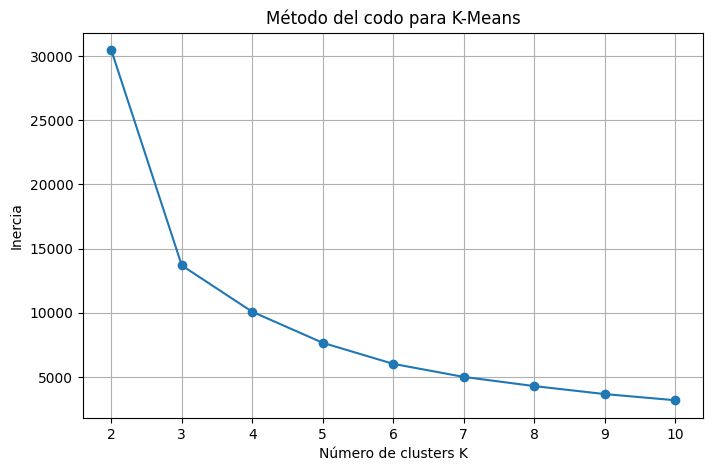

In [ ]:
# Lista para almacenar valores de inercia
inertia = []

# Probar diferentes cantidades de clusters
K_range = range(2, 11)

for k in K_range:
    # Crear y entrenar modelo para cada valor de K
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)

    # Guardar inercia del modelo
    inertia.append(model.inertia_)

# Graficar método del codo
plt.figure(figsize=(8, 5))
plt.plot(list(K_range), inertia, marker="o")
plt.xlabel("Número de clusters K")
plt.ylabel("Inercia")
plt.title("Método del codo para K-Means")
plt.grid(True)
plt.show()


### Interpretación

El método del codo ayuda a elegir un número razonable de clusters. En una imagen con varios colores vivos, aumentar K mejora la representación, pero después de cierto punto la reducción de inercia deja de ser tan fuerte. Por eso un valor intermedio como 6 permite simplificar la imagen sin perder demasiada información visual.


## 9. Aplicación de Mean Shift

Mean Shift busca clusters de forma automática según zonas densas en el espacio de color. A diferencia de K-Means, no exige definir directamente el número de clusters.


In [ ]:
# Estimar ancho de banda para Mean Shift usando la muestra escalada
bandwidth = estimate_bandwidth(X_scaled, quantile=0.2, n_samples=min(5000, len(X_scaled)), random_state=42)

# Crear modelo Mean Shift
meanshift = MeanShift(bandwidth=bandwidth, bin_seeding=True)

# Entrenar modelo y obtener etiquetas
labels_meanshift = meanshift.fit_predict(X_scaled)

# Guardar etiquetas en el DataFrame
df_sample_result["cluster_meanshift"] = labels_meanshift

# Mostrar número de clusters encontrados
n_clusters_ms = len(np.unique(labels_meanshift))
print("Clusters encontrados por Mean Shift:", n_clusters_ms)

# Mostrar distribución de clusters
display(df_sample_result["cluster_meanshift"].value_counts().sort_index())


Clusters encontrados por Mean Shift: 4


,count
cluster_meanshift,
0,7208
1,5608
2,6470
3,714


### Interpretación

Mean Shift determina los grupos según la densidad de los colores. Si encuentra pocos clusters, significa que varios tonos fueron agrupados en familias amplias. Si encuentra muchos, significa que detectó variaciones cromáticas más específicas.


## 10. Evaluación de los modelos

Se calculan métricas internas de clustering para comparar la separación y compactación de los grupos.


In [ ]:
# Función auxiliar para calcular métricas de clustering
def evaluar_clustering(X_data, labels):
    # Validar que existan al menos dos clusters
    if len(np.unique(labels)) < 2:
        return {
            "silhouette": np.nan,
            "davies_bouldin": np.nan,
            "calinski_harabasz": np.nan
        }

    # Calcular métricas principales
    return {
        "silhouette": silhouette_score(X_data, labels),
        "davies_bouldin": davies_bouldin_score(X_data, labels),
        "calinski_harabasz": calinski_harabasz_score(X_data, labels)
    }

# Evaluar K-Means
metricas_kmeans = evaluar_clustering(X_scaled, labels_kmeans)

# Evaluar Mean Shift
metricas_meanshift = evaluar_clustering(X_scaled, labels_meanshift)

# Consolidar resultados
df_metricas = pd.DataFrame([
    {"modelo": "K-Means", **metricas_kmeans},
    {"modelo": "Mean Shift", **metricas_meanshift}
])

display(df_metricas)


,modelo,silhouette,davies_bouldin,calinski_harabasz
0,K-Means,0.463255,0.741925,35843.192048
1,Mean Shift,0.533266,0.727009,24843.784772


### Interpretación

El coeficiente silhouette se interpreta mejor cuando es más alto. Davies-Bouldin se interpreta mejor cuando es más bajo. Calinski-Harabasz se interpreta mejor cuando es más alto. Estas métricas permiten comparar los modelos sin usar etiquetas reales, ya que en segmentación de imagen no se cuenta con una clasificación previa por píxel.


## 11. Visualización de clusters con PCA

Como los datos tienen tres variables RGB, se usa PCA para proyectarlos a dos dimensiones y visualizar la separación de los clusters.


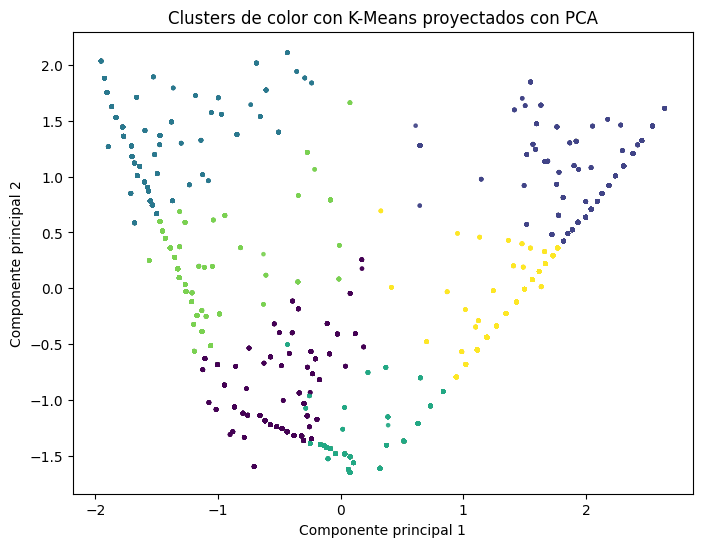

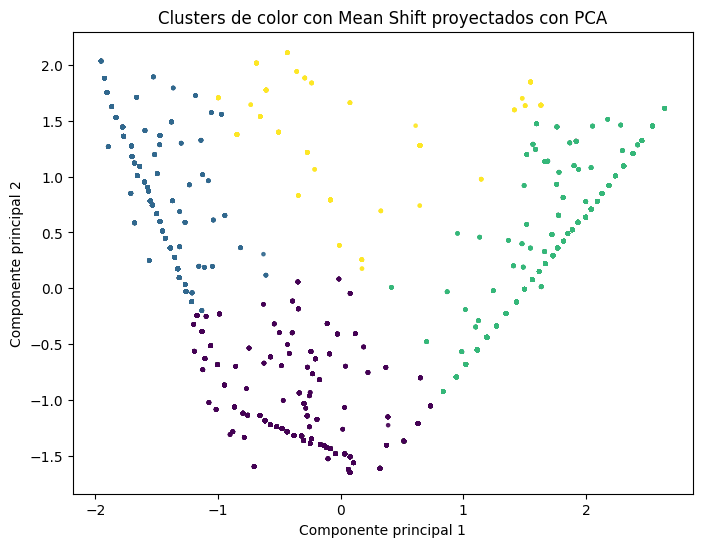

In [ ]:
# Reducir los datos RGB escalados a dos componentes principales
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Visualizar clusters de K-Means
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_kmeans, s=5, alpha=0.6)
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.title("Clusters de color con K-Means proyectados con PCA")
plt.show()

# Visualizar clusters de Mean Shift
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_meanshift, s=5, alpha=0.6)
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.title("Clusters de color con Mean Shift proyectados con PCA")
plt.show()


### Interpretación

La visualización con PCA permite observar si los colores forman grupos separados o si existen transiciones suaves entre tonos. En una imagen artística con degradados, es normal encontrar clusters cercanos, porque algunos colores pasan gradualmente de un tono a otro.


## 12. Reconstrucción segmentada con K-Means

Se aplica el modelo K-Means a todos los píxeles visibles de la imagen y se reconstruye una imagen donde cada píxel toma el color promedio de su cluster.


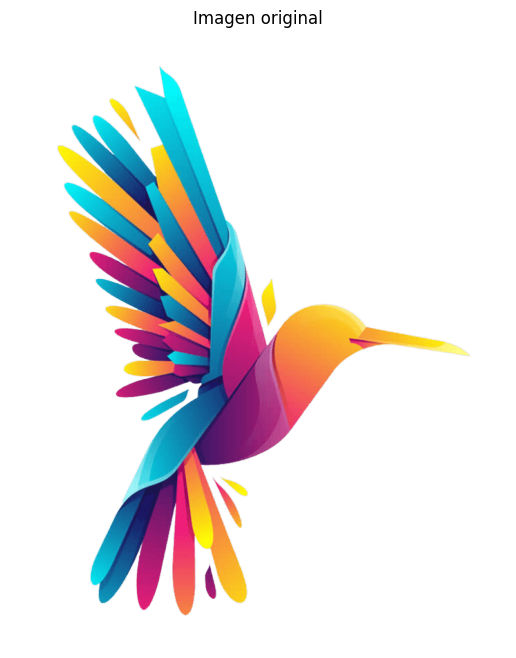

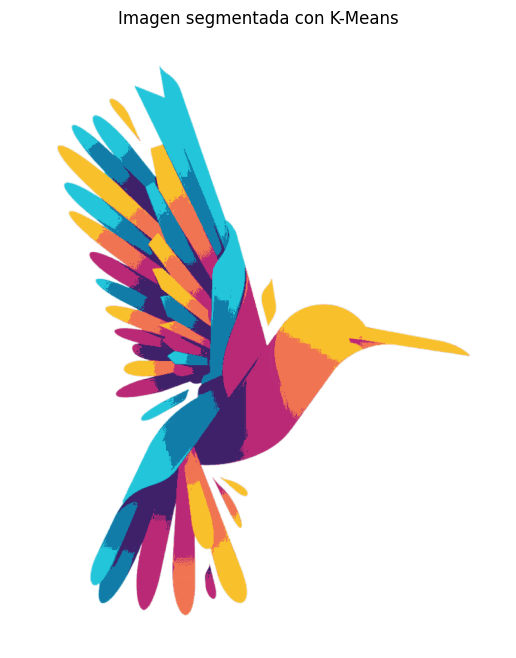

In [ ]:
# Escalar todos los píxeles visibles usando el mismo scaler entrenado
all_pixels_scaled = scaler.transform(df_pixels[["R", "G", "B"]].values)

# Predecir cluster de cada píxel visible con K-Means
all_labels_kmeans = kmeans.predict(all_pixels_scaled)

# Obtener centros de cluster en escala original RGB
centers_rgb = scaler.inverse_transform(kmeans.cluster_centers_)

# Limitar valores al rango válido de imagen
centers_rgb = np.clip(centers_rgb, 0, 255).astype(np.uint8)

# Crear copia vacía para la imagen segmentada
segmented_rgb = rgb.copy()

# Asignar a cada píxel visible el color del centroide correspondiente
segmented_rgb[mask_visible] = centers_rgb[all_labels_kmeans]

# Reconstruir imagen RGBA conservando el canal alfa original
segmented_rgba = np.dstack([segmented_rgb, alpha])

# Visualizar imagen original y segmentada
plt.figure(figsize=(7, 8))
plt.imshow(img_rgba)
plt.axis("off")
plt.title("Imagen original")
plt.show()

plt.figure(figsize=(7, 8))
plt.imshow(segmented_rgba)
plt.axis("off")
plt.title("Imagen segmentada con K-Means")
plt.show()


### Interpretación

La imagen segmentada con K-Means conserva la forma general del colibrí, pero reduce la cantidad de colores. Esto permite identificar las zonas cromáticas principales y observar cómo el algoritmo simplifica degradados y sombras en grupos representativos.


## 13. Reconstrucción segmentada con Mean Shift

Se aplica Mean Shift a todos los píxeles visibles. Para asignar colores representativos, se calcula el promedio RGB de cada cluster identificado.


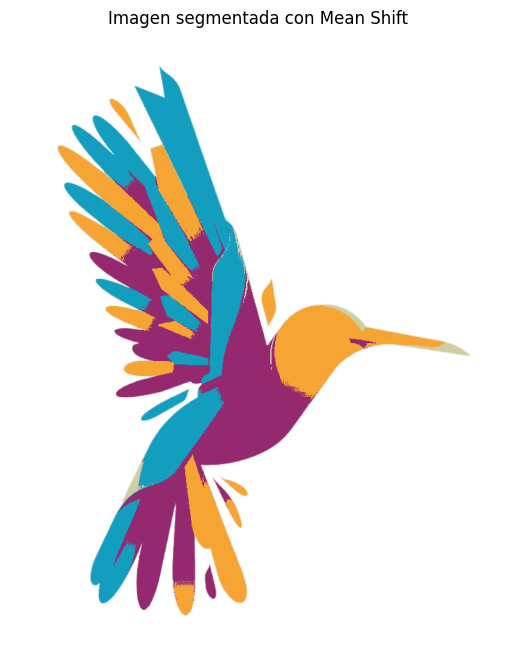

In [ ]:
# Predecir clusters para todos los píxeles visibles con Mean Shift
all_labels_ms = meanshift.predict(all_pixels_scaled)

# Crear arreglo para guardar colores promedio por cluster
unique_ms = np.unique(all_labels_ms)
cluster_colors_ms = {}

for cluster_id in unique_ms:
    # Seleccionar píxeles que pertenecen al cluster actual
    cluster_pixels = df_pixels.values[all_labels_ms == cluster_id]

    # Calcular color promedio del cluster
    cluster_colors_ms[cluster_id] = cluster_pixels.mean(axis=0)

# Crear copia para imagen segmentada con Mean Shift
segmented_rgb_ms = rgb.copy()

# Asignar color promedio a cada cluster
for cluster_id, color in cluster_colors_ms.items():
    segmented_rgb_ms[mask_visible] = segmented_rgb_ms[mask_visible]
    segmented_rgb_ms[mask_visible][all_labels_ms == cluster_id] = color

# La asignación anterior con indexación encadenada puede no modificar la imagen en algunos entornos.
# Por eso se reconstruye de forma segura sobre una matriz plana.
flat_segmented = pixels.copy().astype(float)
for cluster_id, color in cluster_colors_ms.items():
    flat_segmented[all_labels_ms == cluster_id] = color

# Convertir a valores válidos de imagen
flat_segmented = np.clip(flat_segmented, 0, 255).astype(np.uint8)

# Reconstruir imagen RGB completa
segmented_rgb_ms = rgb.copy()
segmented_rgb_ms[mask_visible] = flat_segmented

# Reconstruir imagen RGBA conservando transparencia
segmented_rgba_ms = np.dstack([segmented_rgb_ms, alpha])

# Visualizar resultado
plt.figure(figsize=(7, 8))
plt.imshow(segmented_rgba_ms)
plt.axis("off")
plt.title("Imagen segmentada con Mean Shift")
plt.show()


### Interpretación

Mean Shift genera una segmentación basada en densidades de color. Su resultado puede ser más general o más detallado dependiendo del ancho de banda estimado. Es útil cuando no se desea fijar manualmente el número de clusters.


## 14. Comparación final de resultados

Se comparan los resultados visuales y métricos de K-Means y Mean Shift.


,modelo,silhouette,davies_bouldin,calinski_harabasz
0,K-Means,0.463255,0.741925,35843.192048
1,Mean Shift,0.533266,0.727009,24843.784772


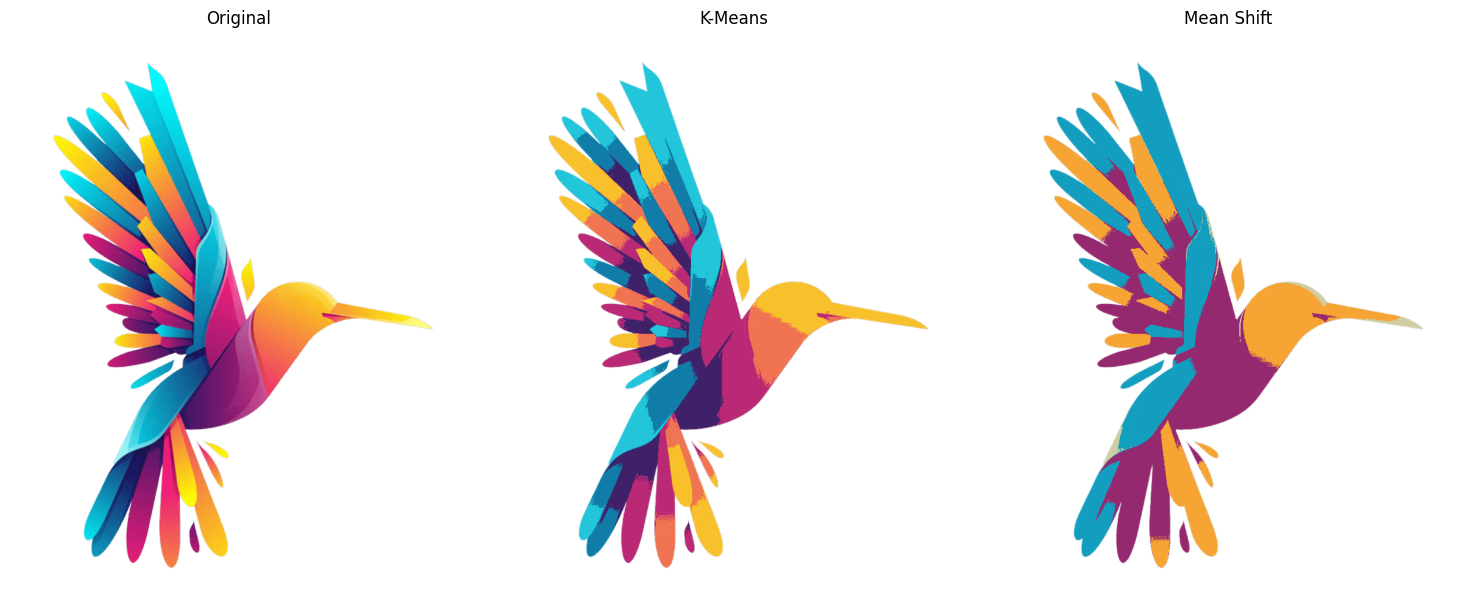

In [ ]:
# Mostrar métricas comparativas
display(df_metricas)

# Comparación visual en una sola fila
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

axes[0].imshow(img_rgba)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(segmented_rgba)
axes[1].set_title("K-Means")
axes[1].axis("off")

axes[2].imshow(segmented_rgba_ms)
axes[2].set_title("Mean Shift")
axes[2].axis("off")

plt.tight_layout()
plt.show()


### Interpretación

K-Means permite controlar directamente el número de colores finales y suele producir una segmentación clara y estable. Mean Shift encuentra automáticamente los clusters, pero su resultado depende bastante del parámetro de ancho de banda. Para esta imagen, K-Means es una opción adecuada porque la imagen tiene colores vivos y definidos que pueden resumirse en un número fijo de grupos cromáticos.


## 15. Conclusiones

El taller permitió aplicar clustering a una imagen real usando los colores de sus píxeles como variables. Se comprobó que el aprendizaje no supervisado puede utilizarse para segmentar imágenes sin etiquetas previas.

K-Means fue útil para reducir la imagen a un conjunto controlado de colores principales, mientras que Mean Shift permitió explorar agrupaciones determinadas por densidad. La comparación visual y las métricas internas muestran que ambos enfoques son válidos, pero K-Means resulta más fácil de controlar e interpretar para una segmentación cromática de este tipo.

En conclusión, el clustering no solo sirve para datasets tabulares tradicionales, sino también para problemas visuales como segmentación, compresión de colores y análisis de regiones en imágenes.
